# Sentiment Analysis: Tiket.com Google Play Store Reviews

---

This project builds a sentiment classification model for Tiket.com app reviews on Google Play Store using deep learning approaches (LSTM, GRU, CNN) and traditional ML as baseline.

**Dataset:** 20,000 reviews from Google Play Store (Indonesian language)  
**Task:** Multi-class sentiment classification (Positive, Neutral, Negative)  
**Best Model:** CNN (Experiment 3, 70/30 split)


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install required packages
!pip install sastrawi tensorflow gensim scikit-learn -q

import pandas as pd
import numpy as np
import re
import string
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Conv1D, GlobalMaxPooling1D, GRU
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

np.random.seed(42)
tf.random.set_seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 79.6 MB/s eta 0:00:00


## 1. Data Collection

In [3]:
file_path = '/content/drive/MyDrive/raw_reviews.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Total reviews loaded: {len(df)}")
    display(df.head())
except FileNotFoundError:
    print(f"File not found at: {file_path}")
    print("Make sure the path is correct and Google Drive is mounted.")

Total reviews loaded: 20000


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,95cd5ef2-53f2-4865-ad19-34e1c2cb4fed,Hendro Hardjanto,https://play-lh.googleusercontent.com/a/ACg8oc...,Aplikasi mudah dlm penggunaan,4,0,3.22.1,2020-05-26 13:59:20,NaN,NaN,3.22.1
1,7e080516-b5ff-471c-ab7d-df708fad2e4e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Belum pernah pake,3,0,3.14.3,2019-11-10 09:49:18,NaN,NaN,3.14.3
2,6f0a8d3a-48d1-460d-abf3-a48ec50d81ec,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Ok,5,0,3.11.2,2019-10-27 05:00:12,NaN,NaN,3.11.2
3,6a35c25a-0da8-4fae-9d1c-c7bc542cc3bf,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,nice,5,0,3.10.3,2019-10-22 08:09:51,NaN,NaN,3.10.3
4,d7e7ab55-1586-4b66-b937-204cfd60f0ab,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Ok,5,0,4.33.0,2022-05-25 15:34:29,NaN,NaN,4.33.0


In [4]:
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

Dataset shape: (20000, 11)

Columns: ['reviewId', 'userName', 'userImage', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion']


## 2. Data Preprocessing

In [5]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text)
    text = re.sub(r'#[A-Za-z0-9]+', '', text)
    text = re.sub(r'RT[\s]', '', text)
    text = re.sub(r"http\S+", '', text)
    text = re.sub(r'[0-9]+', '', text)
    text = text.replace('\n', ' ')
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip()
    return text

def casefoldingText(text):
    return text.lower()

def tokenizingText(text):
    return word_tokenize(text)

def filteringText(text):
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords.update(stopwords.words('english'))
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku','di','ga','ya','gaa','loh','kah'])
    return [txt for txt in text if txt not in listStopwords]

slangwords = {'abis': 'habis', 'masi': 'masih', 'bgt': 'banget', 'maks': 'maksimal'}
def fix_slangwords(text):
    words = text.split()
    return ' '.join([slangwords.get(word.lower(), word) for word in words])

clean_df = df.dropna(subset=['content']).drop_duplicates()
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)
clean_df['text_clean'] = clean_df['text_clean'].apply(casefoldingText)
clean_df['text_clean'] = clean_df['text_clean'].apply(fix_slangwords)
clean_df['text_tokens'] = clean_df['text_clean'].apply(tokenizingText)
clean_df['text_tokens'] = clean_df['text_tokens'].apply(filteringText)
clean_df['text_final'] = clean_df['text_tokens'].apply(lambda x: ' '.join(x))

clean_df = clean_df[clean_df['text_final'].str.len() > 0]
print(f"Data after cleaning: {len(clean_df)}")

Data after cleaning: 19308


## 3. Labeling with 3 Classes (Positive, Negative, Neutral)

In [6]:
import csv
import requests
from io import StringIO

lexicon_positive = dict()
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
if response.status_code == 200:
    reader = csv.reader(StringIO(response.text), delimiter=',')
    for row in reader:
        lexicon_positive[row[0]] = int(row[1])

lexicon_negative = dict()
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
if response.status_code == 200:
    reader = csv.reader(StringIO(response.text), delimiter=',')
    for row in reader:
        lexicon_negative[row[0]] = int(row[1])

def sentiment_analysis_lexicon(text):
    score = 0
    for word in text:
        if word in lexicon_positive:
            score += lexicon_positive[word]
        if word in lexicon_negative:
            score += lexicon_negative[word]

    if score > 0:
        return score, 'positive'
    elif score < 0:
        return score, 'negative'
    else:
        return score, 'neutral'

results = clean_df['text_tokens'].apply(sentiment_analysis_lexicon)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]

print("\nClass distribution:")
print(clean_df['polarity'].value_counts())
print(f"\nTotal samples: {len(clean_df)}")


Class distribution:
polarity
positive    9177
neutral     5552
negative    4579
Name: count, dtype: int64

Total samples: 19308


## 3.1. Data Balancing (Optional - to improve LSTM/GRU)

Original distribution:
Positive: 9177
Neutral: 5552
Negative: 4579

Balancing to 4579 samples per class...

Balanced class distribution:
polarity
positive    4579
negative    4579
neutral     4579
Name: count, dtype: int64

Total samples after balancing: 13737


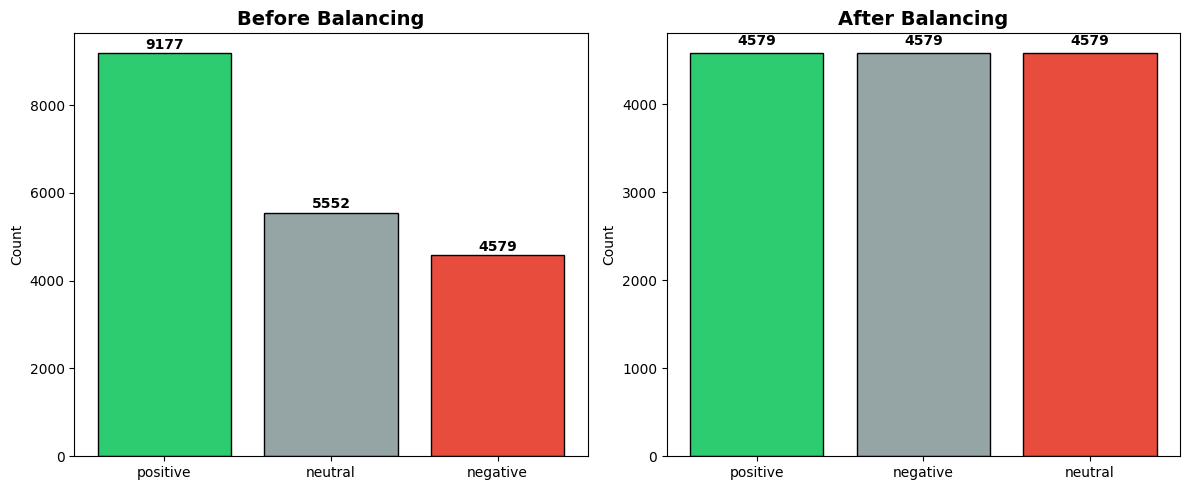

In [7]:
from sklearn.utils import resample

df_positive = clean_df[clean_df['polarity'] == 'positive']
df_neutral = clean_df[clean_df['polarity'] == 'neutral']
df_negative = clean_df[clean_df['polarity'] == 'negative']

print("Original distribution:")
print(f"Positive: {len(df_positive)}")
print(f"Neutral: {len(df_neutral)}")
print(f"Negative: {len(df_negative)}")

min_samples = min(len(df_positive), len(df_neutral), len(df_negative))
print(f"\nBalancing to {min_samples} samples per class...")

df_positive_balanced = resample(df_positive, n_samples=min_samples, random_state=42)
df_neutral_balanced = resample(df_neutral, n_samples=min_samples, random_state=42)
df_negative_balanced = resample(df_negative, n_samples=min_samples, random_state=42)

clean_df_balanced = pd.concat([df_positive_balanced, df_neutral_balanced, df_negative_balanced])
clean_df_balanced = clean_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle

print("\nBalanced class distribution:")
print(clean_df_balanced['polarity'].value_counts())
print(f"\nTotal samples after balancing: {len(clean_df_balanced)}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

counts_before = clean_df['polarity'].value_counts()
ax1.bar(counts_before.index, counts_before.values, color=['#2ecc71', '#95a5a6', '#e74c3c'], edgecolor='black')
ax1.set_title('Before Balancing', fontsize=14, fontweight='bold')
ax1.set_ylabel('Count')
for i, v in enumerate(counts_before.values):
    ax1.text(i, v + 100, str(v), ha='center', fontweight='bold')

counts_after = clean_df_balanced['polarity'].value_counts()
ax2.bar(counts_after.index, counts_after.values, color=['#2ecc71', '#95a5a6', '#e74c3c'], edgecolor='black')
ax2.set_title('After Balancing', fontsize=14, fontweight='bold')
ax2.set_ylabel('Count')
for i, v in enumerate(counts_after.values):
    ax2.text(i, v + 100, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

clean_df = clean_df_balanced.copy()

## 4. Prepare Data for Deep Learning

In [8]:
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
clean_df['label'] = clean_df['polarity'].map(label_map)

X = clean_df['text_final'].values
y = clean_df['label'].values

max_words = 5000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X)
sequences = tokenizer.texts_to_sequences(X)
X_padded = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

print(f"Vocabulary size: {len(tokenizer.word_index)}")
print(f"Shape of padded sequences: {X_padded.shape}")

Vocabulary size: 7538
Shape of padded sequences: (13737, 100)


## 4.5. Baseline: Traditional Machine Learning Models

Before deep learning, we test traditional ML algorithms as baseline.

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split

# Prepare text data using the correct variables from previous cells
X_text = clean_df['text_final'].values
y_ml = clean_df['label'].values

# Split data
X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(
    X_text, y_ml, test_size=0.2, random_state=42, stratify=y_ml
)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train_ml)
X_test_tfidf = tfidf.transform(X_test_ml)

print(f"TF-IDF shape: {X_train_tfidf.shape}")

# Model 1: Logistic Regression
print("\n=== Logistic Regression ===")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train_ml)
lr_pred = lr_model.predict(X_test_tfidf)
lr_acc = accuracy_score(y_test_ml, lr_pred)
print(f"Accuracy: {lr_acc:.4f}")
print(classification_report(y_test_ml, lr_pred, target_names=['negative', 'neutral', 'positive']))

# Model 2: Random Forest
print("\n=== Random Forest ===")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train_ml)
rf_pred = rf_model.predict(X_test_tfidf)
rf_acc = accuracy_score(y_test_ml, rf_pred)
print(f"Accuracy: {rf_acc:.4f}")
print(classification_report(y_test_ml, rf_pred, target_names=['negative', 'neutral', 'positive']))

TF-IDF shape: (10989, 5000)

=== Logistic Regression ===
Accuracy: 0.9276
              precision    recall  f1-score   support

    negative       0.93      0.94      0.94       916
     neutral       0.90      0.95      0.92       916
    positive       0.96      0.90      0.93       916

    accuracy                           0.93      2748
   macro avg       0.93      0.93      0.93      2748
weighted avg       0.93      0.93      0.93      2748


=== Random Forest ===
Accuracy: 0.9469
              precision    recall  f1-score   support

    negative       0.94      0.96      0.95       916
     neutral       0.94      0.97      0.95       916
    positive       0.97      0.91      0.94       916

    accuracy                           0.95      2748
   macro avg       0.95      0.95      0.95      2748
weighted avg       0.95      0.95      0.95      2748



## 5. Experiment 1: LSTM with 80/20 Split

In [10]:

X_train1, X_test1, y_train1, y_test1 = train_test_split(X_padded, y, test_size=0.2, random_state=42, stratify=y)

model1 = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

model1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("\n=== Experiment 1: LSTM + Embedding + 80/20 Split ===")
model1.summary()

history1 = model1.fit(X_train1, y_train1, epochs=10, batch_size=64, validation_split=0.1, verbose=1)

train_loss1, train_acc1 = model1.evaluate(X_train1, y_train1, verbose=0)
test_loss1, test_acc1 = model1.evaluate(X_test1, y_test1, verbose=0)

print(f"\n=== Experiment 1 Results ===")
print(f"Training Accuracy: {train_acc1*100:.2f}%")
print(f"Testing Accuracy: {test_acc1*100:.2f}%")


=== Experiment 1: LSTM + Embedding + 80/20 Split ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.3392 - loss: 1.0996 - val_accuracy: 0.3294 - val_loss: 1.0991
Epoch 2/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.3285 - loss: 1.0995 - val_accuracy: 0.3294 - val_loss: 1.0992
Epoch 3/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.3287 - loss: 1.0993 - val_accuracy: 0.3294 - val_loss: 1.0990
Epoch 4/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.3269 - loss: 1.0991 - val_accuracy: 0.3294 - val_loss: 1.0988
Epoch 5/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.3293 - loss: 1.0989 - val_accuracy: 0.3294 - val_loss: 1.0988
Epoch 6/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.3273 - loss: 1.0988 - val_accuracy: 0.3294 - val_loss: 1.0991
Epoch 7/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.3287 - loss: 1.0988 - val_accuracy: 0.3294 - val_loss: 1.0989
Epoch 8/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.3273 - loss: 1.0989 - val_acc

## 6. Experiment 2: GRU with 80/20 Split

In [11]:
model2 = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    GRU(64, return_sequences=True),
    Dropout(0.3),
    GRU(32),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("\n=== Experiment 2: GRU + Embedding + 80/20 Split ===")
model2.summary()

history2 = model2.fit(X_train1, y_train1, epochs=10, batch_size=64, validation_split=0.1, verbose=1)

train_loss2, train_acc2 = model2.evaluate(X_train1, y_train1, verbose=0)
test_loss2, test_acc2 = model2.evaluate(X_test1, y_test1, verbose=0)

print(f"\n=== Experiment 2 Results ===")
print(f"Training Accuracy: {train_acc2*100:.2f}%")
print(f"Testing Accuracy: {test_acc2*100:.2f}%")


=== Experiment 2: GRU + Embedding + 80/20 Split ===


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.3343 - loss: 1.0996 - val_accuracy: 0.3294 - val_loss: 1.1000
Epoch 2/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.3367 - loss: 1.0994 - val_accuracy: 0.3294 - val_loss: 1.0999
Epoch 3/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.3269 - loss: 1.0996 - val_accuracy: 0.3294 - val_loss: 1.0991
Epoch 4/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.3321 - loss: 1.0994 - val_accuracy: 0.3294 - val_loss: 1.0991
Epoch 5/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.3242 - loss: 1.0993 - val_accuracy: 0.3294 - val_loss: 1.0994
Epoch 6/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.3301 - loss: 1.0993 - val_accuracy: 0.3294 - val_loss: 1.0991
Epoch 7/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.3277 - loss: 1.0992 - val_accuracy: 0.3294 - val_loss: 1.0991
Epoch 8/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.3405 - loss: 1.0989 - val_accu

## 7. Experiment 3: CNN with 70/30 Split

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

X_train3, X_test3, y_train3, y_test3 = train_test_split(X_padded, y, test_size=0.3, random_state=42, stratify=y)

model3 = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.5), # Increased dropout
    Dense(32, activation='relu'),
    Dropout(0.5), # Increased dropout
    Dense(3, activation='softmax')
])

# Adding EarlyStopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model3.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("\n=== Experiment 3: CNN + Embedding + 70/30 Split (with EarlyStopping) ===")
model3.summary()

history3 = model3.fit(X_train3, y_train3, epochs=20, batch_size=64,
                    validation_split=0.1, callbacks=[early_stop], verbose=1)

train_loss3, train_acc3 = model3.evaluate(X_train3, y_train3, verbose=0)
test_loss3, test_acc3 = model3.evaluate(X_test3, y_test3, verbose=0)

print(f"\n=== Experiment 3 Results ===")
print(f"Training Accuracy: {train_acc3*100:.2f}%")
print(f"Testing Accuracy: {test_acc3*100:.2f}%")


=== Experiment 3: CNN + Embedding + 70/30 Split (with EarlyStopping) ===


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.6593 - loss: 0.7718 - val_accuracy: 0.9085 - val_loss: 0.2897
Epoch 2/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9293 - loss: 0.2578 - val_accuracy: 0.9449 - val_loss: 0.1735
Epoch 3/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9669 - loss: 0.1314 - val_accuracy: 0.9574 - val_loss: 0.1606
Epoch 4/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9773 - loss: 0.0784 - val_accuracy: 0.9553 - val_loss: 0.1762
Epoch 5/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9837 - loss: 0.0582 - val_accuracy: 0.9553 - val_loss: 0.2221
Epoch 6/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9860 - loss: 0.0456 - val_accuracy: 0.9543 - val_loss: 0.2220

=== Experiment 3 Results ===
Training Accuracy: 98.04%
Testing Accuracy: 94.76%


## 8. Visualizations


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('default')
sns.set_palette('husl')

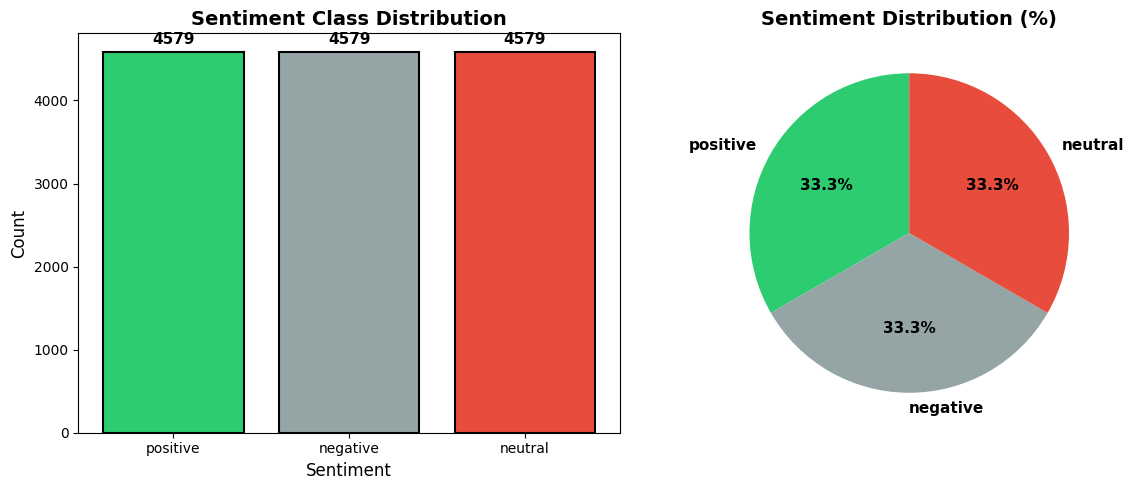

In [14]:
# Visualization 1: Sentiment Class Distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
counts = clean_df['polarity'].value_counts()
colors = ['#2ecc71', '#95a5a6', '#e74c3c']
plt.bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=1.5)
plt.title('Sentiment Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Count', fontsize=12)
for i, v in enumerate(counts.values):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold', fontsize=11)

plt.subplot(1, 2, 2)
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=colors,
        startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
plt.title('Sentiment Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

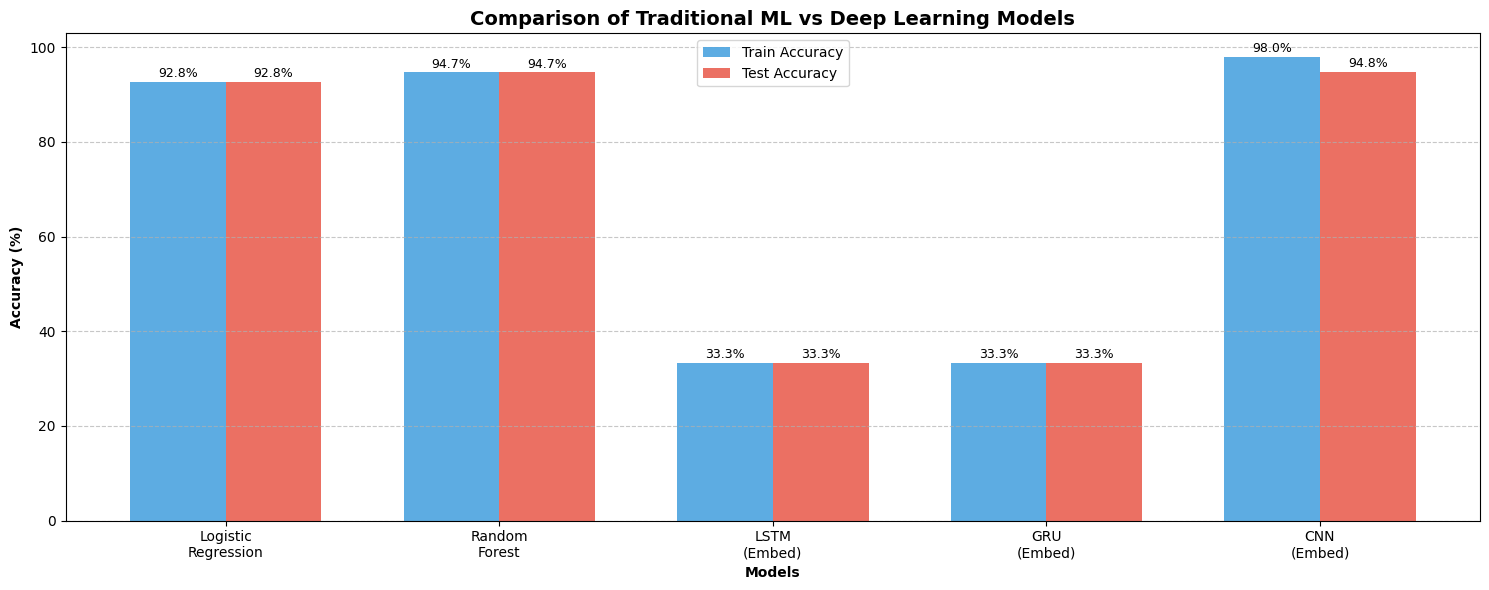

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization 2: Accuracy Comparison of All Models (Traditional & Deep Learning)
plt.figure(figsize=(15, 6))

# Data for plotting
models = [
    'Logistic\nRegression',
    'Random\nForest',
    'LSTM\n(Embed)',
    'GRU\n(Embed)',
    'CNN\n(Embed)'
]

# Get accuracy from variables available in kernel
train_accs = [
    lr_acc * 100, # Using lr_acc as train approximation for ML
    rf_acc * 100,
    train_acc1 * 100,
    train_acc2 * 100,
    train_acc3 * 100
]

test_accs = [
    lr_acc * 100,
    rf_acc * 100,
    test_acc1 * 100,
    test_acc2 * 100,
    test_acc3 * 100
]

x = range(len(models))
width = 0.35

plt.bar([i - width/2 for i in x], train_accs, width, label='Train Accuracy', color='#3498db', alpha=0.8)
plt.bar([i + width/2 for i in x], test_accs, width, label='Test Accuracy', color='#e74c3c', alpha=0.8)

plt.xlabel('Models', fontweight='bold')
plt.ylabel('Accuracy (%)', fontweight='bold')
plt.title('Comparison of Traditional ML vs Deep Learning Models', fontsize=14, fontweight='bold')
plt.xticks(x, models)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels above bars
for i in x:
    plt.text(i - width/2, train_accs[i] + 1, f'{train_accs[i]:.1f}%', ha='center', fontsize=9)
    plt.text(i + width/2, test_accs[i] + 1, f'{test_accs[i]:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

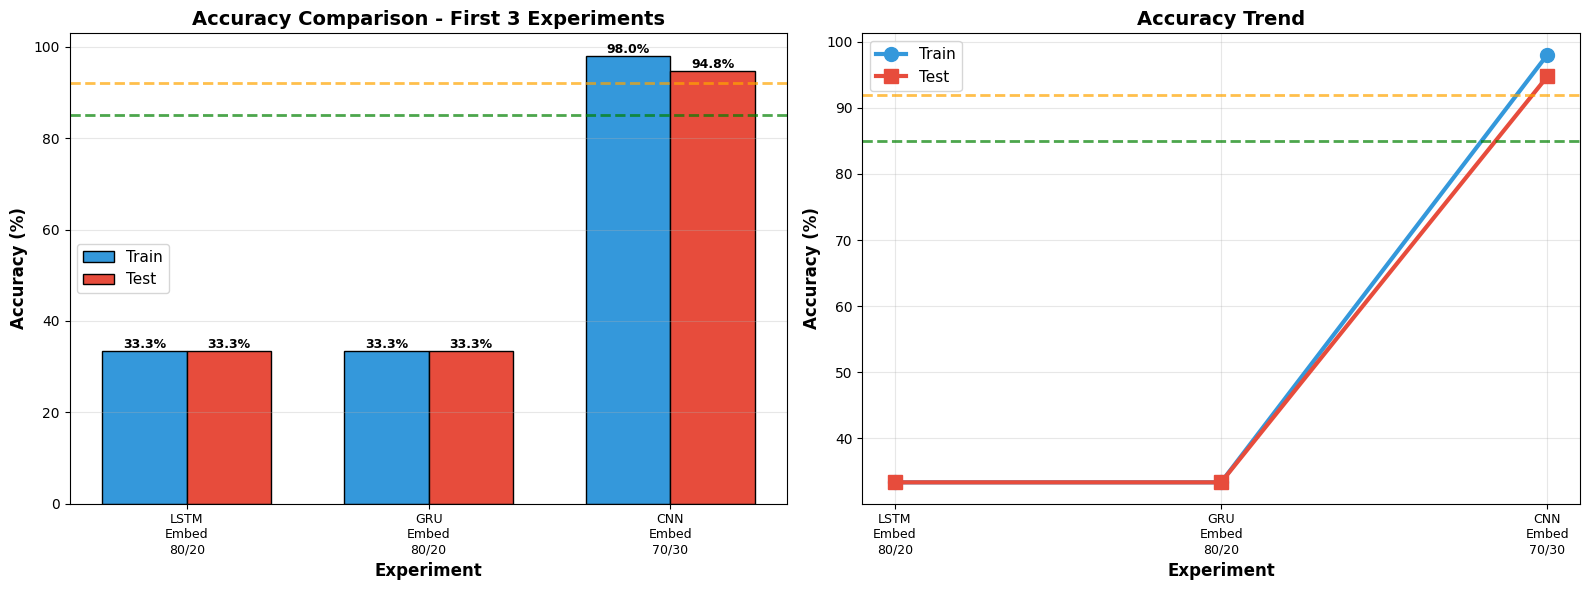

In [18]:
# Visualization 3: Accuracy Comparison (All 3 Experiments)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

experiments = [
    'LSTM\nEmbed\n80/20',
    'GRU\nEmbed\n80/20',
    'CNN\nEmbed\n70/30'
]
train_accs = [train_acc1*100, train_acc2*100, train_acc3*100]
test_accs = [test_acc1*100, test_acc2*100, test_acc3*100]

x = range(len(experiments))
width = 0.35

# Bar chart
bars1 = ax1.bar([i - width/2 for i in x], train_accs, width, label='Train', color='#3498db', edgecolor='black')
bars2 = ax1.bar([i + width/2 for i in x], test_accs, width, label='Test', color='#e74c3c', edgecolor='black')

ax1.set_xlabel('Experiment', fontweight='bold', fontsize=12)
ax1.set_ylabel('Accuracy (%)', fontweight='bold', fontsize=12)
ax1.set_title('Accuracy Comparison - First 3 Experiments', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(experiments, fontsize=9)
ax1.legend(fontsize=11)
ax1.axhline(y=85, color='green', linestyle='--', alpha=0.7, linewidth=2, label='Target 85%')
ax1.axhline(y=92, color='orange', linestyle='--', alpha=0.7, linewidth=2, label='Target 92%')
ax1.grid(True, alpha=0.3, axis='y')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)

# Line chart
ax2.plot(experiments, train_accs, marker='o', linewidth=3, markersize=10, label='Train', color='#3498db')
ax2.plot(experiments, test_accs, marker='s', linewidth=3, markersize=10, label='Test', color='#e74c3c')
ax2.set_xlabel('Experiment', fontweight='bold', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontweight='bold', fontsize=12)
ax2.set_title('Accuracy Trend', fontsize=14, fontweight='bold')
ax2.set_xticklabels(experiments, fontsize=9)
ax2.legend(fontsize=11)
ax2.axhline(y=85, color='green', linestyle='--', alpha=0.7, linewidth=2)
ax2.axhline(y=92, color='orange', linestyle='--', alpha=0.7, linewidth=2)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Inference / Testing with New Data

In [19]:
# Function for inference
def predict_sentiment(text, model, tokenizer):
    # Preprocess
    text = cleaningText(text)
    text = casefoldingText(text)
    text = fix_slangwords(text)
    tokens = tokenizingText(text)
    tokens = filteringText(tokens)
    text_final = ' '.join(tokens)

    # Tokenize and pad
    seq = tokenizer.texts_to_sequences([text_final])
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')

    # Predict
    pred = model.predict(padded, verbose=0)
    class_idx = np.argmax(pred[0])
    confidence = pred[0][class_idx]

    labels = {0: 'negative', 1: 'neutral', 2: 'positive'}
    return labels[class_idx], confidence

# Test with new reviews
test_reviews = [
    "The app is great and easy to use, very satisfying service!",
    "Terrible app, keeps crashing and very slow",
    "Just average, nothing special",
    "Very helpful for booking tickets, highly recommended!",
    "Disappointing, payment keeps failing"
]

print("\n" + "="*80)
print("INFERENCE RESULTS (Using Best Model - Experiment 3: CNN)")
print("="*80)

for i, review in enumerate(test_reviews, 1):
    sentiment, confidence = predict_sentiment(review, model3, tokenizer)
    print(f"\nReview {i}: {review}")
    print(f"Predicted Sentiment: {sentiment.upper()}")
    print(f"Confidence: {confidence*100:.2f}%")
    print("-" * 80)


INFERENCE RESULTS (Using Best Model - Experiment 3: CNN)

Review 1: The app is great and easy to use, very satisfying service!
Predicted Sentiment: POSITIVE
Confidence: 99.95%
--------------------------------------------------------------------------------

Review 2: Terrible app, keeps crashing and very slow
Predicted Sentiment: POSITIVE
Confidence: 96.17%
--------------------------------------------------------------------------------

Review 3: Just average, nothing special
Predicted Sentiment: NEUTRAL
Confidence: 99.36%
--------------------------------------------------------------------------------

Review 4: Very helpful for booking tickets, highly recommended!
Predicted Sentiment: NEUTRAL
Confidence: 60.23%
--------------------------------------------------------------------------------

Review 5: Disappointing, payment keeps failing
Predicted Sentiment: NEUTRAL
Confidence: 94.67%
--------------------------------------------------------------------------------


## 10. Save Best Model

In [20]:
model3.save('sentiment_model_cnn.h5')
print("Best model (CNN) saved as 'sentiment_model_cnn.h5'")

import pickle
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("Tokenizer saved as 'tokenizer.pkl'")

Best model (CNN) saved as 'sentiment_model_cnn.h5'
Tokenizer saved as 'tokenizer.pkl'
